# Tests to compare everything with each other
-------

## 1. schauen welchen ANOVA ich machen muss

### => sind meinen Daten normalverteilt oder weichen sie signifikant von einer Normalverteilung ab! mit *Shapiro-Wilk-Test*
---
## Hypothesentest:
- Nullhypothese (H₀): Die Daten sind normalverteilt
- Alternativhypothese (H₁): Die Daten sind nicht normalverteilt
- p < 0.05 → Daten sind nicht normalverteilt
---
##  Wie funktioniert der Test:
- Werte werden der Größe nach sortiert
- Vergleich mit idealer Normalverteilung (Position der beobachteten Werte werden mit den erwarteten Positionen, wenn die Daten wirklich normalverteilt sind verglichen)
- dann Berechnung einer Teststatistik (Ergebnis ist eine Zahl zwischen 0 und 1; je näher W an 1, desto eher sehen die Daten normalverteilt aus; Test berechnet daraus einen p-Wer)
- p > 0.05 → H₀ wird nicht verworfen =  Daten könnten normalverteilt sein
- p ≤ 0.05 → H₀ wird verworfen = Daten sind nicht normalverteilt

In [155]:
import pandas as pd # für Datenverarbeitung
from scipy.stats import shapiro # Funktion für den Shapiro-wilk-Normalverteilungstest

# Datensatz laden
df = pd.read_csv("all_data.tsv", sep="\t")

# CDR-Regionen und Eigenscahften definieren 
regions = ["CDR_H1", "CDR_H2", "CDR_H3"]
properties = ["mean_hydrophobicity", "mean_charge", "mean_polarity", "mean_mass", "length"]

# Schleife über alle Kombinationen
for region in regions:
    for property in properties:
        # Spaltenname erzeugen
        if property == "length": # prüft ob die aktuelle spalte length ist
            column = f"{region.lower()}_length" # wenn length dann wird dregion klein geschrieben (weil es so im df steht)
        else: # wenn nicht length dann wird region mit property direkt kombiniert 
            column = f"{region}_{property}"

# f-String um Variable direkt in text einzufügen; \n für Zeilenumbruch; {column} Name betrachtete Spalte
        print(f"\n Shapiro-Wilk-Test für: {column}") 


        # Daten pro Gruppen extrahieren
        for group in ["human", "sars_cov2", "influenza"]: # Schleife über die drei Gruppen
            values = df[df["source"] == group][column].dropna() # source und group müssen übereinstimmen
                                                                # [column] nur relevante Spalte (Bsp.CDR_H1_mean_mass)
                                                                # .dropna() Entfernt alle fehlenden Werte (NaN)
            # Shapiro-Wilk-Test anwenden                                       
            if len(values) >= 3: # Gibt die Anzahl der Werte in values zurück; >= 3 → Bedingung: Mindestens 3 Werte erforderlich
                _, p = shapiro(values) # Durchführung Shapiro-Wilk-Test; p → p-Wert (Wahrscheinlichkeit, dass Daten aus Normalverteilung stammen)
                result = " normalverteilt" if p > 0.05 else " nicht normalverteilt" # verkürzter if-else-Ausdruck; p > 0.05 → Bedingung

                # f-String; {group:<10} Gruppe wird eingesetzt mit : Beginn Formatierung < Linksbündig 10 min 10 Zeich.
                # p = p-Wert aus dem Shapiro-Wilk-Test; : Einleitung des Formatierungsteils; .4 4 Nachkommastellen; f Zeige die Zahl als float
                print(f"   Gruppe: {group:<10} → p = {p:.4f} → {result}")  
        



 Shapiro-Wilk-Test für: CDR_H1_mean_hydrophobicity
   Gruppe: human      → p = 0.0000 →  nicht normalverteilt
   Gruppe: sars_cov2  → p = 0.0000 →  nicht normalverteilt
   Gruppe: influenza  → p = 0.0063 →  nicht normalverteilt

 Shapiro-Wilk-Test für: CDR_H1_mean_charge
   Gruppe: human      → p = 0.0000 →  nicht normalverteilt
   Gruppe: sars_cov2  → p = 0.0000 →  nicht normalverteilt
   Gruppe: influenza  → p = 0.0000 →  nicht normalverteilt

 Shapiro-Wilk-Test für: CDR_H1_mean_polarity
   Gruppe: human      → p = 0.0000 →  nicht normalverteilt
   Gruppe: sars_cov2  → p = 0.0000 →  nicht normalverteilt
   Gruppe: influenza  → p = 0.0022 →  nicht normalverteilt

 Shapiro-Wilk-Test für: CDR_H1_mean_mass
   Gruppe: human      → p = 0.0000 →  nicht normalverteilt
   Gruppe: sars_cov2  → p = 0.0000 →  nicht normalverteilt
   Gruppe: influenza  → p = 0.0001 →  nicht normalverteilt

 Shapiro-Wilk-Test für: cdr_h1_length
   Gruppe: human      → p = 0.0000 →  nicht normalverteilt
   Gruppe:

# Unesere Daten sind nicht normalverteilt !
---

## => dann schauen wie die Varianz ist mit Levene-Test
### ! Nullhypothese (H₀): Die Varianzen der Gruppen sind gleich.
### - p-Wert < 0.05 → Ablehnung der Nullhypothese → Varianzen sind unterschiedlich → Welch-ANOVA
### - p-Wert ≥ 0.05 → Nullhypothese wird nicht abgelehnt → Varianzen sind gleich →  klassische ANOVA möglich

In [156]:
from scipy.stats import levene

# Lade den Datensatz
df = pd.read_csv("all_data.tsv", sep="\t")

# Regionen (CDRs)
regions = ["CDR_H1", "CDR_H2", "CDR_H3"]

# Eigenschaften
features = ["mean_hydrophobicity", "mean_charge", "mean_polarity", "mean_mass", "length"]

# Schleife über alle Kombinationen
for region in regions:
    for feature in features:
        # Wenn Feature 'length' ist, passe den Spaltennamen an
        if feature == "length":
            region_lower = region.lower()  # z. B. "cdr_h2"
            column = f"{region_lower}_length"  # ergibt z. B. "cdr_h2_length"
        else:
            column = f"{region}_{feature}"

        print(f"\n Levene-Test für: {column}")

        if column not in df.columns:
            print("   !  Spalte nicht vorhanden – übersprungen")
            continue

        # Gruppen extrahieren
        group_human = df[df["source"] == "human"][column].dropna()
        group_sars = df[df["source"] == "sars_cov2"][column].dropna()
        group_influenza = df[df["source"] == "influenza"][column].dropna()

        if len(group_human) > 2 and len(group_sars) > 2 and len(group_influenza) > 2:
            stat, p = levene(group_human, group_sars, group_influenza)
            print(f"   Teststatistik = {stat:.4f}, p-Wert = {p:.4f}")

            if p < 0.05:
                print("   !  Varianzen signifikant unterschiedlich → Welch-ANOVA empfohlen")
            else:
                print("     Varianzen gleich → klassische ANOVA möglich")
        else:
            print("   !  Nicht genug Daten in einer oder mehreren Gruppen")



 Levene-Test für: CDR_H1_mean_hydrophobicity
   Teststatistik = 7.0819, p-Wert = 0.0009
   !  Varianzen signifikant unterschiedlich → Welch-ANOVA empfohlen

 Levene-Test für: CDR_H1_mean_charge
   Teststatistik = 8.0631, p-Wert = 0.0003
   !  Varianzen signifikant unterschiedlich → Welch-ANOVA empfohlen

 Levene-Test für: CDR_H1_mean_polarity
   Teststatistik = 2.5913, p-Wert = 0.0752
     Varianzen gleich → klassische ANOVA möglich

 Levene-Test für: CDR_H1_mean_mass
   Teststatistik = 42.4279, p-Wert = 0.0000
   !  Varianzen signifikant unterschiedlich → Welch-ANOVA empfohlen

 Levene-Test für: cdr_h1_length
   Teststatistik = 97.3028, p-Wert = 0.0000
   !  Varianzen signifikant unterschiedlich → Welch-ANOVA empfohlen

 Levene-Test für: CDR_H2_mean_hydrophobicity
   Teststatistik = 14.6962, p-Wert = 0.0000
   !  Varianzen signifikant unterschiedlich → Welch-ANOVA empfohlen

 Levene-Test für: CDR_H2_mean_charge
   Teststatistik = 1.0185, p-Wert = 0.3613
     Varianzen gleich → klassi

### => unsere Daten haben zum größten Teil eine ungleiche Varianz => Welch-ANOVA empfohlen
---

## 2. jetzt Welche ANOVA macehn für alle 

In [157]:

import pingouin as pg

# Lade den Datensatz
df = pd.read_csv("all_data.tsv", sep="\t")

# Regionen und Eigenschaften
regions = ["CDR_H1", "CDR_H2", "CDR_H3"]
features = ["mean_hydrophobicity", "mean_charge", "mean_polarity", "mean_mass", "length"]

# Schleife über alle Kombinationen
for region in regions:
    for feature in features:
        # Korrekte Spaltenbezeichnung erzeugen
        if feature == "length":
            column = f"{region.lower()}_length"  # z. B. cdr_h2_length
        else:
            column = f"{region}_{feature}"

        print(f"\n Welch-ANOVA für: {column}")

        if column not in df.columns:
            print("   !  Spalte nicht vorhanden – übersprungen")
            continue

        # DataFrame für Welch-ANOVA vorbereiten
        data = df[['source', column]].dropna()
        data = data.rename(columns={'source': 'group', column: 'value'})

        # Prüfen ob genug Daten vorhanden sind
        if data['group'].value_counts().min() < 3:
            print("   !  Nicht genug Daten in mindestens einer Gruppe")
            continue

        # Welch-ANOVA durchführen
        result = pg.welch_anova(dv='value', between='group', data=data)

        # Ausgabe
        f_val = result['F'].values[0]
        p_val = result['p-unc'].values[0]
        print(f"   F-Wert = {f_val:.4f}, p-Wert = {p_val:.4f}")

        if p_val < 0.05:
            print("     Signifikanter Unterschied zwischen Gruppen")
        else:
            print("   !  Kein signifikanter Unterschied gefunden")




 Welch-ANOVA für: CDR_H1_mean_hydrophobicity
   F-Wert = 47.8956, p-Wert = 0.0000
     Signifikanter Unterschied zwischen Gruppen

 Welch-ANOVA für: CDR_H1_mean_charge
   F-Wert = 2.0243, p-Wert = 0.1331
   !  Kein signifikanter Unterschied gefunden

 Welch-ANOVA für: CDR_H1_mean_polarity
   F-Wert = 42.2548, p-Wert = 0.0000
     Signifikanter Unterschied zwischen Gruppen

 Welch-ANOVA für: CDR_H1_mean_mass
   F-Wert = 46.2291, p-Wert = 0.0000
     Signifikanter Unterschied zwischen Gruppen

 Welch-ANOVA für: cdr_h1_length
   F-Wert = 24.8402, p-Wert = 0.0000
     Signifikanter Unterschied zwischen Gruppen

 Welch-ANOVA für: CDR_H2_mean_hydrophobicity
   F-Wert = 13.8959, p-Wert = 0.0000
     Signifikanter Unterschied zwischen Gruppen

 Welch-ANOVA für: CDR_H2_mean_charge
   F-Wert = 12.7290, p-Wert = 0.0000
     Signifikanter Unterschied zwischen Gruppen

 Welch-ANOVA für: CDR_H2_mean_polarity
   F-Wert = 3.3595, p-Wert = 0.0355
     Signifikanter Unterschied zwischen Gruppen

 Welch

### => wir haben viele signifikante Unterschiede 
---

## 3. Games-Howell-Test (post-hoc Analyse)
### => um herauszufinden welche Gruppen sich voneinander unterscheiden
### => Ergebnisse dann in einem Datensatz abspeicher 

In [158]:

# Datensatz laden
df = pd.read_csv("all_data.tsv", sep="\t")

# Regionen und Merkmale
regions = ["CDR_H1", "CDR_H2", "CDR_H3"]
features = ["mean_hydrophobicity", "mean_charge", "mean_polarity", "mean_mass", "length"]

# Liste für Ergebnisse
all_results = []

# Schleife über alle Spalten
for region in regions:
    for feature in features:
        # Spaltenname erzeugen
        if feature == "length":
            column = f"{region.lower()}_length"
        else:
            column = f"{region}_{feature}"

        print(f"\n Games-Howell-Test für: {column}")

        if column not in df.columns:
            print("   !  Spalte nicht vorhanden – übersprungen")
            continue

        # Daten vorbereiten
        data = df[['source', column]].dropna()
        data = data.rename(columns={"source": "group", column: "value"})

        # Genug Daten?
        if data['group'].value_counts().min() < 3:
            print("   !  Nicht genug Daten in mindestens einer Gruppe – übersprungen")
            continue

        # Welch-ANOVA
        anova = pg.welch_anova(dv='value', between='group', data=data)
        p_anova = anova['p-unc'].values[0]

        if p_anova < 0.05:
            # Post-hoc Games-Howell
            gh = pg.pairwise_gameshowell(dv='value', between='group', data=data)
            gh['feature'] = column  # Spalte hinzufügen
            all_results.append(gh[['feature', 'A', 'B', 'pval', 'hedges']])
            print("  !  Signifikanter Unterschied → Ergebnisse gespeichert.")
        else:
            print("   X Kein signifikanter Unterschied – kein Post-hoc nötig")

# Alle Ergebnisse zusammenfassen und speichern
if all_results:
    final_df = pd.concat(all_results, ignore_index=True)
    final_df.to_csv("games_howell_results.tsv", sep="\t", index=False)
    print("\n Alle Ergebnisse gespeichert in 'games_howell_results.tsv'")
else:
    print("\n!  Keine signifikanten Ergebnisse zum Speichern vorhanden.")



 Games-Howell-Test für: CDR_H1_mean_hydrophobicity
  !  Signifikanter Unterschied → Ergebnisse gespeichert.

 Games-Howell-Test für: CDR_H1_mean_charge
   X Kein signifikanter Unterschied – kein Post-hoc nötig

 Games-Howell-Test für: CDR_H1_mean_polarity
  !  Signifikanter Unterschied → Ergebnisse gespeichert.

 Games-Howell-Test für: CDR_H1_mean_mass
  !  Signifikanter Unterschied → Ergebnisse gespeichert.

 Games-Howell-Test für: cdr_h1_length
  !  Signifikanter Unterschied → Ergebnisse gespeichert.

 Games-Howell-Test für: CDR_H2_mean_hydrophobicity
  !  Signifikanter Unterschied → Ergebnisse gespeichert.

 Games-Howell-Test für: CDR_H2_mean_charge
  !  Signifikanter Unterschied → Ergebnisse gespeichert.

 Games-Howell-Test für: CDR_H2_mean_polarity
  !  Signifikanter Unterschied → Ergebnisse gespeichert.

 Games-Howell-Test für: CDR_H2_mean_mass
  !  Signifikanter Unterschied → Ergebnisse gespeichert.

 Games-Howell-Test für: cdr_h2_length
  !  Signifikanter Unterschied → Ergebni

In [159]:
# TSV-Datei einlesen
df = pd.read_csv("games_howell_results.tsv", sep="\t")

# Ersten Zeilen anzeigen
print(df.head(10))  # Zeigt die ersten 10 Zeilen

                      feature          A          B          pval    hedges
0  CDR_H1_mean_hydrophobicity      human  influenza  1.635381e-08  0.528740
1  CDR_H1_mean_hydrophobicity      human  sars_cov2  2.896606e-08 -0.276256
2  CDR_H1_mean_hydrophobicity  influenza  sars_cov2  0.000000e+00 -0.755797
3        CDR_H1_mean_polarity      human  influenza  0.000000e+00 -0.754776
4        CDR_H1_mean_polarity      human  sars_cov2  4.412166e-01 -0.059127
5        CDR_H1_mean_polarity  influenza  sars_cov2  0.000000e+00  0.722813
6            CDR_H1_mean_mass      human  influenza  1.076139e-12  0.720439
7            CDR_H1_mean_mass      human  sars_cov2  1.314393e-12  0.355693
8            CDR_H1_mean_mass  influenza  sars_cov2  7.382169e-04 -0.311560
9               cdr_h1_length      human  influenza  1.914021e-10 -0.851402


## p-Wert (p-value) zeigt: ob Unterschied zwischen zwei Gruppen statistisch signifikant ist.

#### p < 0.05: Unterschied ist signifikant → Es gibt sehr wahrscheinlich einen echten Unterschied zwischen den Gruppen.
#### p ≥ 0.05: Kein signifikanter Unterschied → Der Unterschied könnte durch Zufall entstanden sein

## Hedges: Maß für die Effektstärke – also wie groß der Unterschied zwischen zwei Gruppen inhaltlich ist, unabhängig davon, ob er signifikant ist
---

# Ergebnisse Veranschaulischen


## ! „Wie stark unterscheiden sich Gruppenmittelwerte in einer Eigenschaft?“
---


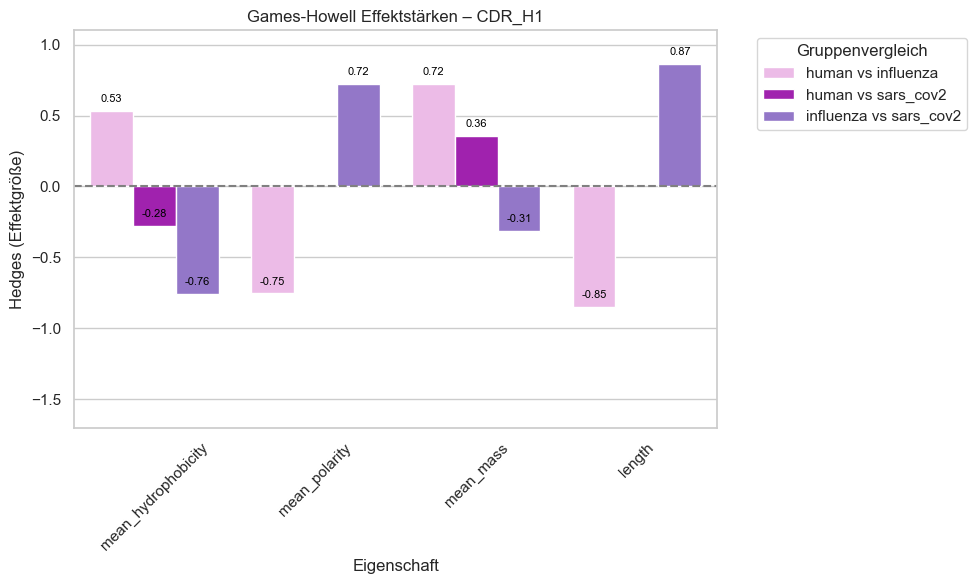

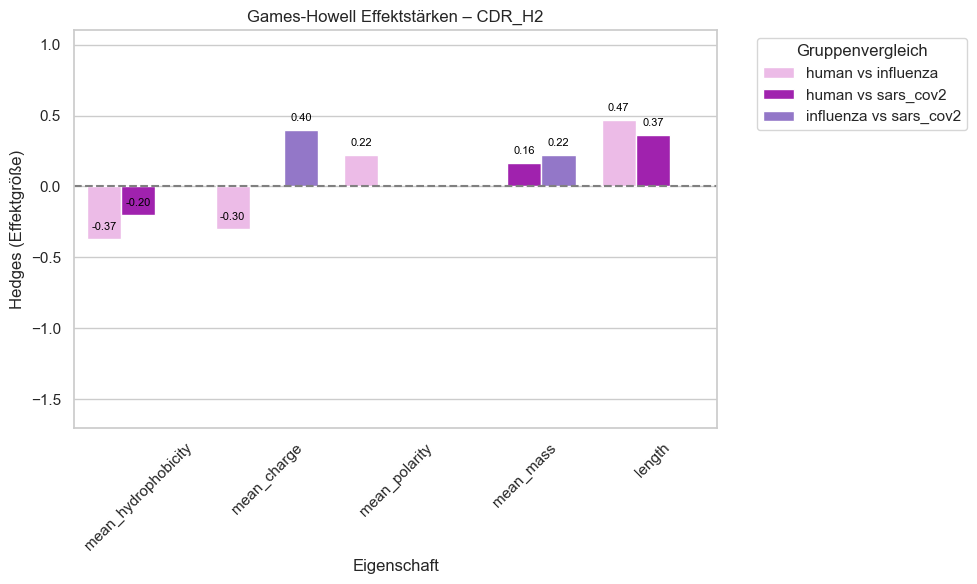

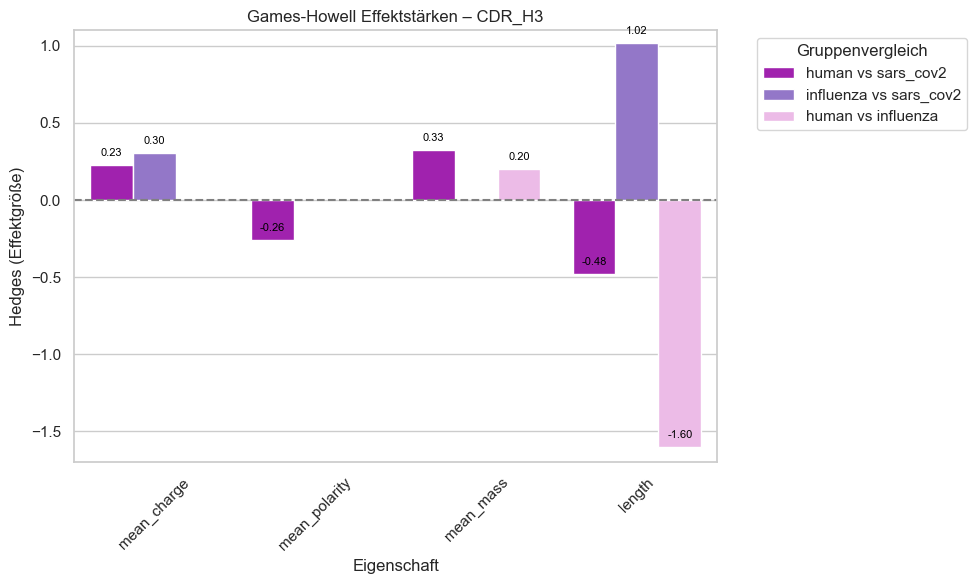

In [160]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Daten laden
df = pd.read_csv("games_howell_results.tsv", sep="\t")

# Nur signifikante Ergebnisse
df_sig = df[df["pval"] < 0.05].copy()
df_sig["pair"] = df_sig["A"] + " vs " + df_sig["B"]
df_sig["region"] = df_sig["feature"].str.extract(r'(CDR_H\d|cdr_h\d)', expand=False)
df_sig["property"] = df_sig["feature"].str.replace(r'(CDR_H\d|cdr_h\d)_?', '', regex=True)

# Farbpalette für Gruppenvergleiche
custom_colors = {
    "human vs influenza": "#f4b3ee",
    "human vs sars_cov2": "#b30bc5",
    "influenza vs sars_cov2": "#8F6AD5"
}

# Regionen durchgehen
regions = ["CDR_H1", "CDR_H2", "CDR_H3"]

for region in regions:
    df_region = df_sig[df_sig["region"].str.lower() == region.lower()]
    if df_region.empty:
        continue

    plt.figure(figsize=(10, 6))
    ax = sns.barplot(data=df_region, x="property", y="hedges", hue="pair", palette=custom_colors)

    # Effektgrößen als Zahlen beschriften
    for container in ax.containers:
        for bar in container:
            height = bar.get_height()
            if height != 0:
                ax.annotate(f"{height:.2f}",
                            xy=(bar.get_x() + bar.get_width() / 2, height),
                            xytext=(0, 5),
                            textcoords="offset points",
                            ha='center', va='bottom',
                            fontsize=8, color='black')

    plt.axhline(0, color="gray", linestyle="--")
    plt.title(f"Games-Howell Effektstärken – {region}")
    plt.ylabel("Hedges (Effektgröße)")
    plt.xlabel("Eigenschaft")
    plt.xticks(rotation=45)
    plt.ylim(-1.70, 1.10)  # 🔸 Hier feste y-Achse setzen
    plt.legend(title="Gruppenvergleich", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


## Interpretation der Diagramme

### => Ergebnisse mit der größten Effektstärke 
---

## CDR H3

### 1. mean_charge
#### - human vs. sars_cov2: g ≈ 0.23 → kleiner Effekt
#### - influenza vs. sars_cov2: g ≈ 0.30 → kleiner Effekt
#### ➤ SARS-CoV-2 hat eine geringere mittlere Ladung als die anderen beiden Gruppen.
---

### 2. mean_polarity
#### -human vs. sars_cov2: g ≈ -0.26 → kleiner Effekt
#### ➤ Die mittlere Polarität bei human ist niedriger als bei SARS-CoV-2.
---

### 3. mean_mass
####  -human vs. sars_cov2: g ≈ 0.33 → kleiner Effekt
#### - human vs. influenza: g ≈ 0.20 → kleiner Effekt
#### ➤ Human-Antikörper in CDR_H3 sind massereicher als bei den Viren.
---
### 4. length
#### - influenza vs. sars_cov2: g ≈ 1.02 → großer Effekt
#### - human vs. sars_cov2: g ≈ -0.48 → kleiner Effekt
#### - human vs. influenza: g ≈ -1.60 → großer Effekt
#### ➤ Influenza-CDR_H3 ist deutlich länger als bei human und SARS-CoV-2.
#### ➤ Human-CDR_H3 ist am kürzesten – sehr starker Unterschied zu influenza !!!
#### => Die größten Unterschiede findet man beim Länge der CDR_H3-Region: Influenza-Antikörper haben hier deutlich längere CDR_H3-Loops
---


## CDR H2

### 1. mean_hydrophobicity
#### - human vs influenza: g = -0.37
#### - human vs sars_cov2: g = -0.20
#### => Human-CDR_H2 ist weniger hydrophob als Influenza oder SARS-CoV-2
#### - Effektstärken: klein bis moderat
---

### 2. mean_charge
#### - influenza vs sars_cov2: g = 0.40
#### - human vs influenza: g = -0.30
#### => Influenza hat höhere mittlere Ladung als human und SARS-CoV-2
#### => Effekt klein bis mittel
---

### 3. mean_polarity
#### - human vs influenza: g = 0.22
#### => Influenza scheint eine etwas geringere Polarität zu haben 
#### => Effekte: klein
---

### 4. mean_mass
#### - human vs sars_cov2: g = 0.16
#### - influenza vs sars_cov2: g = 0.22
#### => human und Influenza etwas Massenreicher als sars_cov2
#### => Effekte: klein
---

### 5. length
#### - human vs influenza: g = 0.47
#### - human vs sars_cov2: g = 0.37
#### => Human-Antikörper haben längere CDR_H2-Regionen als die viralen Gruppen
#### => Effektgrößen nahe der mittleren Schwelle
---



## CDR H1 

### 1. mean_hydrophobicity
####  - human vs influenza: g = 0.53 → Human ist hydrophober
#### - human vs sars_cov2: g = -0.28 → Human weniger hydrophob als SARS-CoV-2
#### - influenza vs sars_cov2: g = -0.76 → Influenza deutlich weniger hydrophob als SARS-CoV-2
#### => SARS-CoV-2 ist die hydrophobste Gruppe in CDR_H1
---

### 2. mean_polarity
#### - human vs influenza: g = -0.75 → Influenza ist polarer als Human
#### - influenza vs sars_cov2: g = 0.72 → Influenza ist polarer als SARS-CoV-2
#### => Influenza ist am polarsten
---

### 3. mean_mass
#### - human vs influenza: g = 0.72 → Human ist schwerer als influenza
#### - influenza vs sars_cov2: g = -0.31 → Influenza leichter als SARS-CoV-2
#### - human vs sars_cov2: g = 0.36 → Human > SARS-CoV-2
#### => Masse: SARS-CoV-2 < influenza < human
---
### 4. length
#### - human vs influenza: g = -0.85 → Human-CDR_H1 ist kürzer als Influenza 
#### - influenza vs sars_cov2: g = 0.87 → Influenza-CDR_H1 ist länger als SARS-CoV-2
#### => Influenza am längsten 
#### => Größter Effekt im ganzen Plot → Länge unterscheidet sich sehr deutlich
---



## Interpretation der Ergebnisse:
## ! es weden nur gruppen angezeigt die einen signifikanten p-Wert haben
#### - X-Achse: Eigenschaften 
#### - Y-Achse: Effektstärke (Hedges) → misst die Größe des Unterschieds zwischen Gruppen
#### => Wert > 0: Gruppe B hat im Mittel größere Werte als Gruppe A.
#### => Wert < 0: Gruppe A hat im Mittel größere Werte als Gruppe B.
#### => Wert ≈ 0: Kein oder nur kleiner Unterschied
---